<a href="https://colab.research.google.com/github/twillixa/Data_and_code_1/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

In [4]:

from google.colab import files
uploaded= files.upload()

Saving reading.csv to reading.csv


In [5]:
reading= pd.read_csv('reading.csv')
print(reading)

    id      score        age      group
0    1  59.988809  10.937378    Control
1    2  60.394867  10.261197    Control
2    3  70.023947  11.795009    Control
3    4  41.477072   6.471665    Control
4    5  29.154968   6.321822    Control
5    6  58.840086   9.449869    Control
6    7  50.623417   8.326680    Control
7    8  47.286413   9.062330    Control
8    9  49.619884   8.196888    Control
9   10  45.129387   7.307585    Control
10  11  59.923276   9.857299    Control
11  12  71.224683  10.516890    Control
12  13  39.129885   6.553486    Control
13  14  49.018066   7.843848    Control
14  15  69.208849  11.952481    Control
15  16  40.342950   6.713886    Control
16  17  56.227609   9.152648    Control
17  18  30.190947   6.247606    Control
18  19  66.501797  11.633335    Control
19  20  34.186597   6.403011    Control
20  21  31.460080   6.178400    Control
21  22  34.199829   6.787729    Control
22  23  65.471060  10.913789    Control
23  24  64.089557  11.380072    Control


Let's start by examining the average score of both groups

/tmp/ipykernel_5327/3593594747.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([(reading[reading['group']=="Treatment"]['score']),(reading[reading['group']=="Control"]['score'])],labels=["Treatment","Control"])


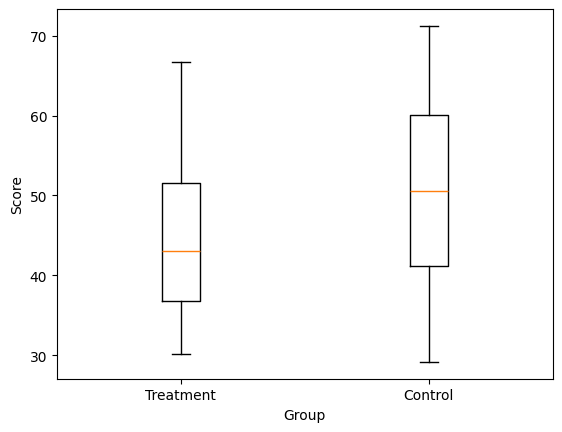

The mean of the treament group is 44.8  And the mean of the control group is 50.6


In [24]:
plt.boxplot([(reading[reading['group']=="Treatment"]['score']),(reading[reading['group']=="Control"]['score'])],labels=["Treatment","Control"])
plt.ylabel("Score")
plt.xlabel("Group")
plt.show()
print("The mean of the treament group is",(reading[reading['group']=="Treatment"]['score']).mean().round(1)," And the mean of the control group is",(reading[reading['group']=="Control"]['score']).mean().round(1))

In [13]:
stats.ttest_ind(reading[reading['group']=="Treatment"]['score'],reading[reading['group']=="Control"]['score'])

TtestResult(statistic=np.float64(-1.8552524202341374), pvalue=np.float64(0.06864451633153601), df=np.float64(58.0))

From the t test we can see that the groups aren't significantly different at the 5% level. This result would suggest that the treatment doesn't affect reading abilities or reduce it a little, another hypothesis is that the person on the treatment group are the one with reading problem and that the treatment doesn't compensate this natural gap. Let's investigate further

<Axes: xlabel='age', ylabel='Density'>

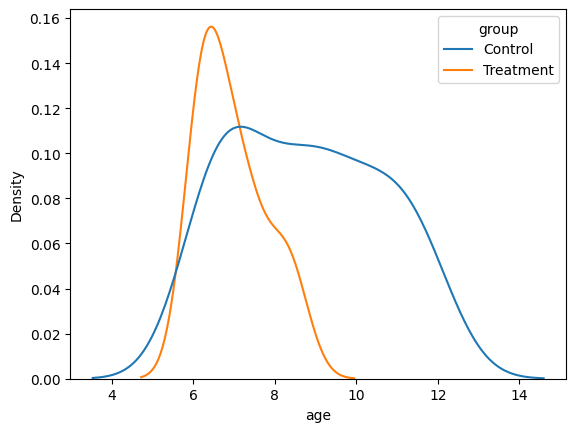

In [10]:
sns.kdeplot(reading,x=reading['age'],hue=reading['group'])

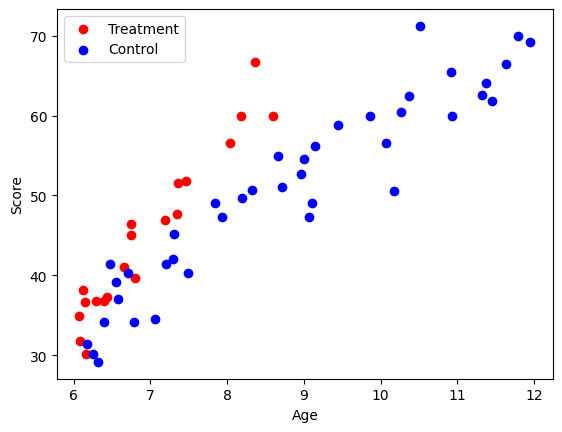

In [49]:
plt.scatter(reading[reading['group']=="Treatment"]['age'],reading[reading['group']=="Treatment"]['score'],c="red",label="Treatment")
plt.scatter(reading[reading['group']=="Control"]['age'],reading[reading['group']=="Control"]['score'],c="blue",label="Control")
plt.xlabel("Age")
plt.ylabel("Score")
plt.legend()
plt.show()

In [20]:
ols=smf.ols("score~group",reading).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  score   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     3.442
Date:                Sat, 03 Oct 2026   Prob (F-statistic):             0.0686
Time:                        20:40:11   Log-Likelihood:                -230.09
No. Observations:                  60   AIC:                             464.2
Df Residuals:                      58   BIC:                             468.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             50.5630      1.801     28.075      0.000      46.958      54.168
group[T.Treatment]    -5.7872      3.119     -1.855      0.069     -12.031       0.457
==============================================================================
Omnibus:                        4.998   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.082   Jarque-Bera (JB):                2.162
Skew:                           0.066   Prob(JB):                        0.339
Kurtosis:                       2.080   Cond. No.                         2.41
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

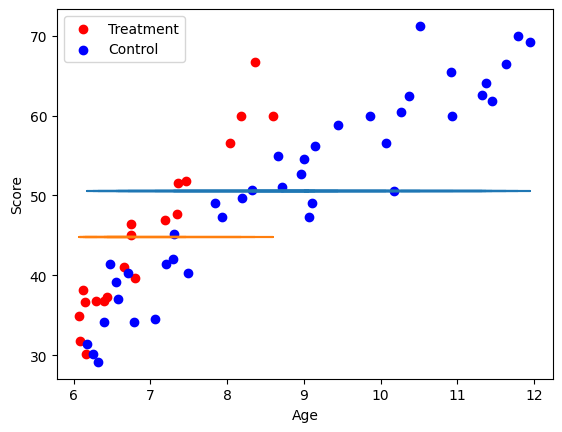

In [49]:
pred=ols.predict(reading)
plt.scatter(reading[reading['group']=="Treatment"]['age'],reading[reading['group']=="Treatment"]['score'],c="red",label="Treatment")
plt.scatter(reading[reading['group']=="Control"]['age'],reading[reading['group']=="Control"]['score'],c="blue",label="Control")
plt.xlabel("Age")
plt.ylabel("Score")
plt.legend()
plt.plot(reading[reading['group']=="Control"]['age'],pred[reading['group']=="Control"])
plt.plot(reading[reading['group']=="Treatment"]['age'],pred[reading['group']=="Treatment"])

In [42]:
ols_age=smf.ols("score~age+group",reading).fit()
ols_age.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  score   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     173.0
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           6.16e-25
Time:                        22:30:33   Log-Likelihood:                -173.13
No. Observations:                  60   AIC:                             352.3
Df Residuals:                      57   BIC:                             358.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -7.8639      3.324     -2.366      0.021     -14.520      -1.208
group[T.Treatment]     6.3771      1.393      4.578      0.000       3.587       9.167
age                    6.6457      0.370     17.985      0.000       5.906       7.386
==============================================================================
Omnibus:                        0.633   Durbin-Watson:                   2.068
Prob(Omnibus):                  0.729   Jarque-Bera (JB):                0.386
Skew:                           0.196   Prob(JB):                        0.824
Kurtosis:                       3.013   Cond. No.                         50.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

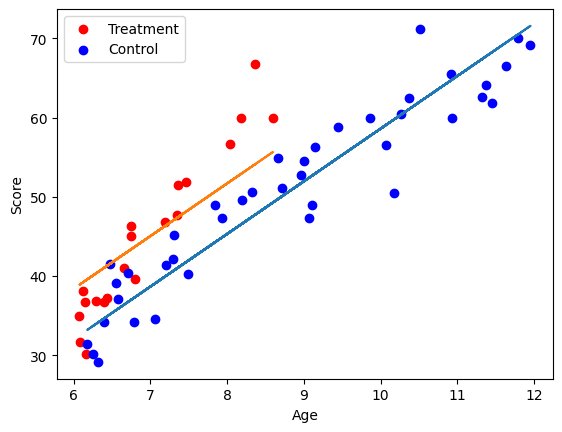

In [48]:
pred=ols_age.predict(reading)
plt.scatter(reading[reading['group']=="Treatment"]['age'],reading[reading['group']=="Treatment"]['score'],c="red",label="Treatment")
plt.scatter(reading[reading['group']=="Control"]['age'],reading[reading['group']=="Control"]['score'],c="blue",label="Control")
plt.xlabel("Age")
plt.ylabel("Score")
plt.legend()
plt.plot(reading[reading['group']=="Control"]['age'],pred[reading['group']=="Control"])
plt.plot(reading[reading['group']=="Treatment"]['age'],pred[reading['group']=="Treatment"])

In [26]:
ols_int_age=smf.ols("score~age+group+age*group",reading).fit()
ols_int_age.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  score   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     189.6
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.70e-29
Time:                        22:16:47   Log-Likelihood:                -159.45
No. Observations:                  60   AIC:                             326.9
Df Residuals:                      56   BIC:                             335.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -3.2489      2.790     -1.164      0.249      -8.839       2.341
group[T.Treatment]       -36.0307      7.539     -4.779      0.000     -51.134     -20.928
age                        6.1207      0.311     19.693      0.000       5.498       6.743
age:group[T.Treatment]     5.9539      1.047      5.688      0.000       3.857       8.051
==============================================================================
Omnibus:                        0.210   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.901   Jarque-Bera (JB):                0.005
Skew:                           0.013   Prob(JB):                        0.998
Kurtosis:                       3.036   Cond. No.                         145.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

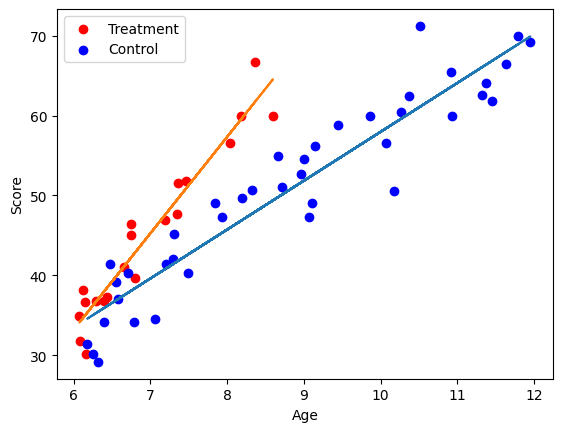

In [47]:
pred=ols_int_age.predict(reading)
plt.scatter(reading[reading['group']=="Treatment"]['age'],reading[reading['group']=="Treatment"]['score'],c="red",label="Treatment")
plt.scatter(reading[reading['group']=="Control"]['age'],reading[reading['group']=="Control"]['score'],c="blue",label="Control")
plt.xlabel("Age")
plt.ylabel("Score")
plt.legend()
plt.plot(reading[reading['group']=="Control"]['age'],pred[reading['group']=="Control"])
plt.plot(reading[reading['group']=="Treatment"]['age'],pred[reading['group']=="Treatment"])

In [32]:
reading['age6']=reading['age']-6
ols_int_bis=smf.ols("score~age6*group",reading).fit()
ols_int_bis.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  score   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     189.6
Date:                Sat, 03 Oct 2026   Prob (F-statistic):           2.70e-29
Time:                        22:22:08   Log-Likelihood:                -159.45
No. Observations:                  60   AIC:                             326.9
Df Residuals:                      56   BIC:                             335.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  33.4755      1.035     32.334      0.000      31.402      35.550
group[T.Treatment]         -0.3073      1.623     -0.189      0.850      -3.558       2.943
age6                        6.1207      0.311     19.693      0.000       5.498       6.743
age6:group[T.Treatment]     5.9539      1.047      5.688      0.000       3.857       8.051
==============================================================================
Omnibus:                        0.210   Durbin-Watson:                   2.013
Prob(Omnibus):                  0.901   Jarque-Bera (JB):                0.005
Skew:                           0.013   Prob(JB):                        0.998
Kurtosis:                       3.036   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

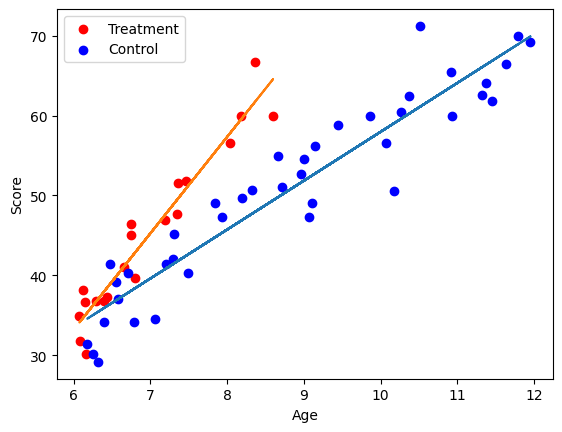

In [46]:
pred=ols_int_bis.predict(reading)
plt.scatter(reading[reading['group']=="Treatment"]['age'],reading[reading['group']=="Treatment"]['score'],c="red",label="Treatment")
plt.scatter(reading[reading['group']=="Control"]['age'],reading[reading['group']=="Control"]['score'],c="blue",label="Control")
plt.xlabel("Age")
plt.ylabel("Score")
plt.legend()
plt.plot(reading[reading['group']=="Control"]['age'],pred[reading['group']=="Control"])
plt.plot(reading[reading['group']=="Treatment"]['age'],pred[reading['group']=="Treatment"])